
MATRIZ FUNDAMENTAL N
[[6.11111111 4.16666667 2.5        2.5       ]
 [2.77777778 4.16666667 2.5        2.5       ]
 [0.55555556 0.83333333 2.5        2.5       ]
 [0.         0.         0.         2.5       ]]

TEMPO MEDIO ATE ABSORCAO
Estado 0: 15.2778 ciclos
Estado 1: 11.9444 ciclos
Estado 2: 6.3889 ciclos
Estado 3: 2.5000 ciclos

PROBABILIDADES DE ABSORCAO
Estado 0: 1.000000
Estado 1: 1.000000
Estado 2: 1.000000
Estado 3: 1.000000
Estado 4: 1.000000

PROBABILIDADE DE ESTAR NO ESTADO 4 NO 4º CICLO
0.014400000000000003

PROBABILIDADE MONTE CARLO DE ESTAR NO ESTADO 4
NO 4º CICLO
0.01452


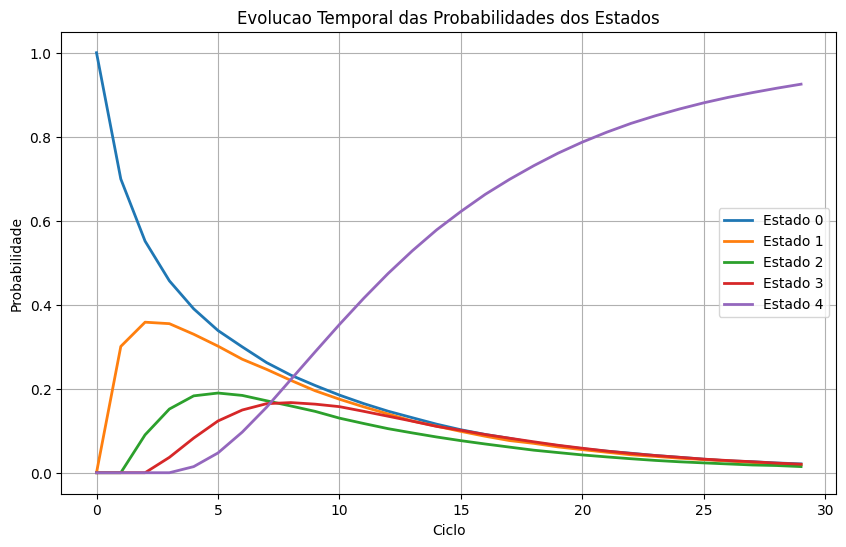

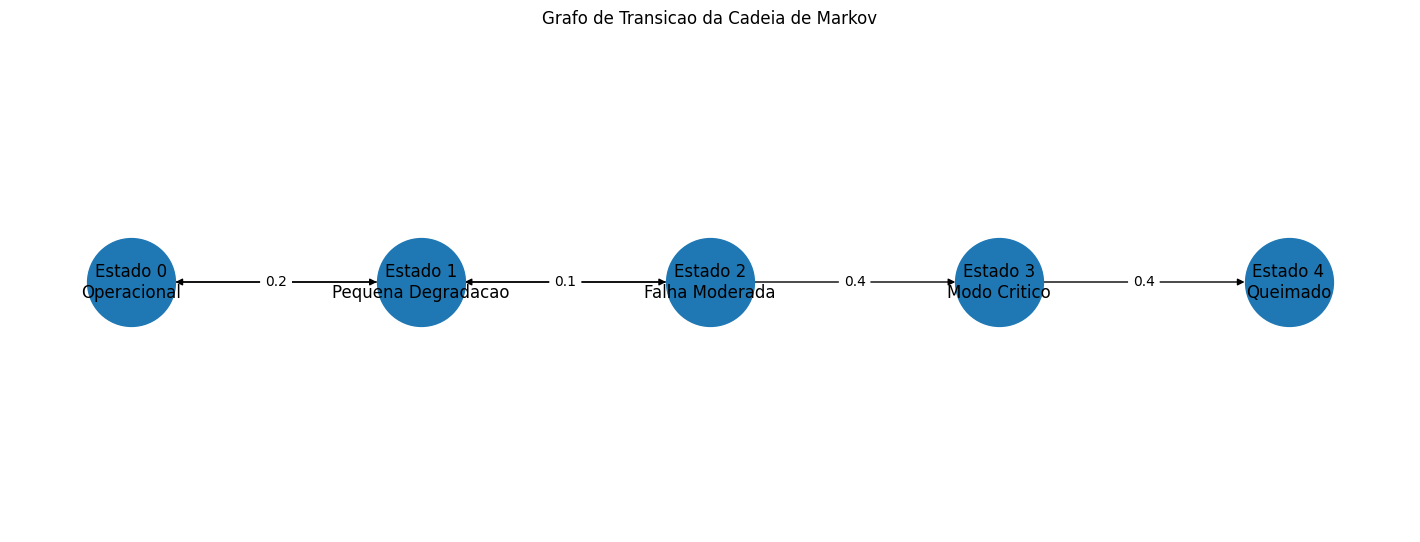

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# =====================================================
# PARAMETROS
# =====================================================

n = 100000              # numero de simulacoes
chain_length = 30       # numero de ciclos

# estado inicial (sensor operacional)
x0 = [1, 0, 0, 0, 0]

# =====================================================
# MATRIZ DE TRANSICAO
# =====================================================

probabilidades_transicao = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

# =====================================================
# ITEM (d) - MATRIZ FUNDAMENTAL
# =====================================================

Q = probabilidades_transicao[0:4, 0:4]
R = probabilidades_transicao[0:4, 4:5]

I = np.eye(Q.shape[0])

N = np.linalg.inv(I - Q)

print("\n====================================================")
print("MATRIZ FUNDAMENTAL N")
print("====================================================")
print(N)

# =====================================================
# ITEM (e) - TEMPO MEDIO ATE ABSORCAO
# =====================================================

uns = np.ones((Q.shape[0], 1))

tempo_medio = N @ uns

print("\n====================================================")
print("TEMPO MEDIO ATE ABSORCAO")
print("====================================================")

for i in range(4):
    print(f"Estado {i}: {tempo_medio[i,0]:.4f} ciclos")

# =====================================================
# ITEM (f) - PROBABILIDADE DE ABSORCAO
# =====================================================

B = N @ R

print("\n====================================================")
print("PROBABILIDADES DE ABSORCAO")
print("====================================================")

for i in range(4):
    print(f"Estado {i}: {B[i,0]:.6f}")

print(f"Estado 4: {1.0:.6f}")

# =====================================================
# ITEM (c) - SOLUCAO ANALITICA
# =====================================================

P4 = np.linalg.matrix_power(probabilidades_transicao, 4)

print("\n====================================================")
print("PROBABILIDADE DE ESTAR NO ESTADO 4 NO 4º CICLO")
print("====================================================")
print(P4[0,4])

# =====================================================
# SIMULACAO MONTE CARLO
# =====================================================

contagem_estados = np.zeros((chain_length, 5))

for j in range(n):

    r1 = np.random.uniform(0, 1)

    acumulada = np.cumsum(x0)

    valor_inicial = np.argmax(acumulada > r1)

    chain = np.zeros(chain_length, dtype=int)

    chain[0] = valor_inicial

    for i in range(1, chain_length):

        linha_atual = probabilidades_transicao[chain[i-1]]

        acumulada = np.cumsum(linha_atual)

        r = np.random.uniform(0, 1)

        chain[i] = np.argmax(acumulada > r)

    for t in range(chain_length):
        contagem_estados[t, chain[t]] += 1

# =====================================================
# PROBABILIDADES DOS ESTADOS
# =====================================================

probabilidades = contagem_estados / n

print("\n====================================================")
print("PROBABILIDADE MONTE CARLO DE ESTAR NO ESTADO 4")
print("NO 4º CICLO")
print("====================================================")
print(probabilidades[4,4])

# =====================================================
# EVOLUCAO TEMPORAL DAS PROBABILIDADES
# =====================================================

plt.figure(figsize=(10,6))

for estado in range(5):
    plt.plot(
        probabilidades[:, estado],
        linewidth=2,
        label=f'Estado {estado}'
    )

plt.xlabel('Ciclo')
plt.ylabel('Probabilidade')
plt.title('Evolucao Temporal das Probabilidades dos Estados')
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# GRAFO DE TRANSICAO
# =====================================================

G = nx.DiGraph()

nomes = {
    0: "Estado 0\nOperacional",
    1: "Estado 1\nPequena Degradacao",
    2: "Estado 2\nFalha Moderada",
    3: "Estado 3\nModo Critico",
    4: "Estado 4\nQueimado"
}

for i in range(5):
    G.add_node(i)

for i in range(5):
    for j in range(5):

        if i != j and probabilidades_transicao[i,j] > 0:

            G.add_edge(
                i,
                j,
                weight=probabilidades_transicao[i,j]
            )

pos = {
    0: (0, 0),
    1: (2, 0),
    2: (4, 0),
    3: (6, 0),
    4: (8, 0)
}

plt.figure(figsize=(14,5))

nx.draw(
    G,
    pos,
    labels=nomes,
    with_labels=True,
    node_size=4000
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title('Grafo de Transicao da Cadeia de Markov')
plt.axis('off')
plt.show()